# Transfer Learning Comparison: ResNet vs ViT
## Super AI Engineer Program -- Level 1 (FLEX / Reference)

**What this notebook does:** Side-by-side comparison of ResNet (PyTorch-native) vs ViT (HuggingFace Trainer) on the SAME dataset. Shows when each approach wins and demonstrates a simple ensemble.

**This is FLEX content** -- meant as a take-home reference, not a live walkthrough.

**Pipeline steps:**
1. Setup & load the same dataset from the Classification Pipeline notebook
2. ResNet-18 fine-tuning (abbreviated -- reuses pattern from classification-pipeline.ipynb)
3. ViT fine-tuning with HuggingFace Trainer
4. Comparison table: accuracy, training time, model size, GPU memory
5. Simple ensemble: average predictions from both models
6. "When to use what" decision guide

**Runtime:** ~5-7 minutes total on free Google Colab T4 GPU

---
## Cell 1: Setup & Load Dataset
Same dataset and setup as the Classification Pipeline notebook. Run that notebook first, OR run the setup code below.

In [2]:
# STEP 1: Setup -- install everything for BOTH approaches
!pip install torch torchvision transformers datasets evaluate matplotlib scikit-learn pandas accelerate -q

import os, time, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder, Flowers102
from sklearn.metrics import classification_report, accuracy_score
from PIL import Image

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [3]:
# STEP 1b: Download and prepare dataset (same as classification-pipeline.ipynb)
DATA_ROOT = "data"
SUBSET_CLASSES = 10
FLOWER_NAMES = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells",
    "sweet pea", "english marigold", "tiger lily", "moon orchid",
    "bird of paradise", "monkshood", "globe thistle"
]

if not os.path.exists(os.path.join(DATA_ROOT, "train")):
    print("Downloading Flowers-102 dataset...")
    flowers_train = Flowers102(root="./flowers_raw", split="train", download=True)
    flowers_val = Flowers102(root="./flowers_raw", split="val", download=True)
    flowers_test = Flowers102(root="./flowers_raw", split="test", download=True)

    all_images = []
    for dataset in [flowers_train, flowers_val, flowers_test]:
        for idx in range(len(dataset)):
            img_path = dataset._image_files[idx]
            label = dataset._labels[idx]
            if label < SUBSET_CLASSES:
                all_images.append((img_path, label))

    random.shuffle(all_images)
    n_total = len(all_images)
    n_train = int(n_total * 0.7)
    n_val = int(n_total * 0.15)

    splits = {"train": all_images[:n_train], "val": all_images[n_train:n_train+n_val], "test": all_images[n_train+n_val:]}
    for split_name, split_imgs in splits.items():
        for img_path, label in split_imgs:
            class_name = FLOWER_NAMES[label].replace(" ", "_")
            dest_dir = os.path.join(DATA_ROOT, split_name, class_name)
            os.makedirs(dest_dir, exist_ok=True)
            dest = os.path.join(dest_dir, os.path.basename(str(img_path)))
            if not os.path.exists(dest):
                shutil.copy2(str(img_path), dest)
    print("Dataset ready!")
else:
    print("Dataset already exists!")

# Create PyTorch datasets
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_transform)
val_dataset = ImageFolder(os.path.join(DATA_ROOT, 'val'), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(train_dataset.classes)
class_names = [c.replace("_", " ") for c in train_dataset.classes]
print(f"Classes: {NUM_CLASSES}, Train: {len(train_dataset)}, Val: {len(val_dataset)}")

100%|██████████| 345M/345M [00:25<00:00, 13.3MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.06MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 44.1MB/s]

Dataset ready!
Classes: 10, Train: 365, Val: 78


---
## Cell 2: Approach A -- ResNet-18 (PyTorch-native)
Standard transfer learning with vanilla PyTorch. Same code as classification-pipeline.ipynb, condensed.

In [4]:
# APPROACH A: ResNet-18 with PyTorch-native training loop
print("=" * 60)
print("APPROACH A: ResNet-18 (PyTorch-native transfer learning)")
print("=" * 60)

# Load & prepare model
resnet_model = models.resnet18(weights='IMAGENET1K_V1')
for param in resnet_model.parameters():
    param.requires_grad = False
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, NUM_CLASSES)
resnet_model = resnet_model.to(device)

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Measure GPU memory before training
if device.type == 'cuda':
    torch.cuda.reset_peak_memory_stats()

# Train
NUM_EPOCHS = 5
resnet_start = time.time()

for epoch in range(NUM_EPOCHS):
    resnet_model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Validate
    resnet_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet_model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    scheduler.step()
    print(f"  Epoch {epoch+1}/{NUM_EPOCHS} | Train Acc: {100.*correct/total:.1f}% | Val Acc: {100.*val_correct/val_total:.1f}%")

resnet_time = time.time() - resnet_start
resnet_val_acc = 100. * val_correct / val_total

# Get GPU memory used
resnet_gpu_mem = torch.cuda.max_memory_allocated() / 1e6 if device.type == 'cuda' else 0

# Count parameters
resnet_total_params = sum(p.numel() for p in resnet_model.parameters())
resnet_trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)

print(f"\nResNet-18 Results:")
print(f"  Val Accuracy: {resnet_val_acc:.1f}%")
print(f"  Training time: {resnet_time:.1f}s")
print(f"  Total params: {resnet_total_params:,}")
print(f"  Trainable params: {resnet_trainable:,}")
print(f"  Peak GPU memory: {resnet_gpu_mem:.0f} MB")

APPROACH A: ResNet-18 (PyTorch-native transfer learning)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


  Epoch 1/5 | Train Acc: 26.6% | Val Acc: 46.2%
  Epoch 2/5 | Train Acc: 53.7% | Val Acc: 73.1%
  Epoch 3/5 | Train Acc: 76.2% | Val Acc: 84.6%
  Epoch 4/5 | Train Acc: 80.8% | Val Acc: 84.6%
  Epoch 5/5 | Train Acc: 81.4% | Val Acc: 83.3%

ResNet-18 Results:
  Val Accuracy: 83.3%
  Training time: 23.6s
  Total params: 11,181,642
  Trainable params: 5,130
  Peak GPU memory: 301 MB


---
## Cell 3: Approach B -- ViT (HuggingFace Trainer)
Fine-tuning a Vision Transformer using the HuggingFace ecosystem. This is the pattern from live-demo.ipynb but applied to the same dataset for fair comparison.

In [5]:
# APPROACH B: ViT with HuggingFace Trainer
print("=" * 60)
print("APPROACH B: ViT-Base (HuggingFace Trainer)")
print("=" * 60)

from transformers import ViTForImageClassification, ViTImageProcessor
from transformers import TrainingArguments, Trainer
import evaluate
from datasets import Dataset, Features, ClassLabel, Image as HFImage

# Load ViT processor and model
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

vit_model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
    id2label={i: c for i, c in enumerate(class_names)},
    label2id={c: i for i, c in enumerate(class_names)},
)

vit_total_params = sum(p.numel() for p in vit_model.parameters())
vit_trainable = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"ViT loaded. Total params: {vit_total_params:,}, Trainable: {vit_trainable:,}")

# Build HuggingFace datasets from our ImageFolder structure
def load_images_from_folder(root_dir):
    """Load images from ImageFolder structure into HuggingFace Dataset."""
    images, labels = [], []
    classes_sorted = sorted(os.listdir(root_dir))
    class_to_idx = {c: i for i, c in enumerate(classes_sorted)}
    for cls in classes_sorted:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.startswith('.'):
                continue
            fpath = os.path.join(cls_dir, fname)
            images.append(fpath)
            labels.append(class_to_idx[cls])
    return Dataset.from_dict({"image": images, "label": labels}).cast_column("image", HFImage())

hf_train = load_images_from_folder(os.path.join(DATA_ROOT, "train"))
hf_val = load_images_from_folder(os.path.join(DATA_ROOT, "val"))
print(f"HF datasets: train={len(hf_train)}, val={len(hf_val)}")

# Preprocessing function
def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    inputs = processor(images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

hf_train_processed = hf_train.with_transform(preprocess)
hf_val_processed = hf_val.with_transform(preprocess)

# Metric
accuracy_metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=eval_pred.label_ids)

APPROACH B: ViT-Base (HuggingFace Trainer)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT loaded. Total params: 85,806,346, Trainable: 85,806,346
HF datasets: train=365, val=78


In [6]:
# Train ViT with HuggingFace Trainer
if device.type == 'cuda':
    torch.cuda.reset_peak_memory_stats()

training_args = TrainingArguments(
    output_dir="./vit-flowers",
    num_train_epochs=3,               # Fewer epochs -- ViT converges faster with Trainer
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,               # Small LR for fine-tuning
    fp16=True if device.type == 'cuda' else False,
    logging_steps=10,
    load_best_model_at_end=True,
    remove_unused_columns=False,
    report_to="none",
    metric_for_best_model="accuracy",
)

trainer = Trainer(
    model=vit_model,
    args=training_args,
    train_dataset=hf_train_processed,
    eval_dataset=hf_val_processed,
    compute_metrics=compute_metrics,
)

vit_start = time.time()
trainer.train()
vit_time = time.time() - vit_start

# Evaluate
vit_results = trainer.evaluate(hf_val_processed)
vit_val_acc = vit_results['eval_accuracy'] * 100

vit_gpu_mem = torch.cuda.max_memory_allocated() / 1e6 if device.type == 'cuda' else 0

print(f"\nViT Results:")
print(f"  Val Accuracy: {vit_val_acc:.1f}%")
print(f"  Training time: {vit_time:.1f}s")
print(f"  Total params: {vit_total_params:,}")
print(f"  Trainable params: {vit_trainable:,}")
print(f"  Peak GPU memory: {vit_gpu_mem:.0f} MB")

Epoch,Training Loss,Validation Loss,Accuracy
1,1.492969,1.114852,0.948718
2,0.689988,0.610430,0.987179
3,0.388903,0.488286,0.987179


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


ViT Results:
  Val Accuracy: 98.7%
  Training time: 43.9s
  Total params: 85,806,346
  Trainable params: 85,806,346
  Peak GPU memory: 2534 MB


---
## Cell 4: Head-to-Head Comparison

HEAD-TO-HEAD COMPARISON: ResNet-18 vs ViT-Base
                  Metric            ResNet-18                ViT-Base
        Val Accuracy (%)                83.3%                   98.7%
       Training Time (s)                23.6s                   43.9s
        Total Parameters           11,181,642              85,806,346
    Trainable Parameters                5,130              85,806,346
    Peak GPU Memory (MB)               301 MB                 2534 MB
Model File Size (approx)               ~45 MB                 ~330 MB
               Framework     PyTorch (native)     HuggingFace Trainer
        Training Pattern Manual training loop Trainer API (automated)


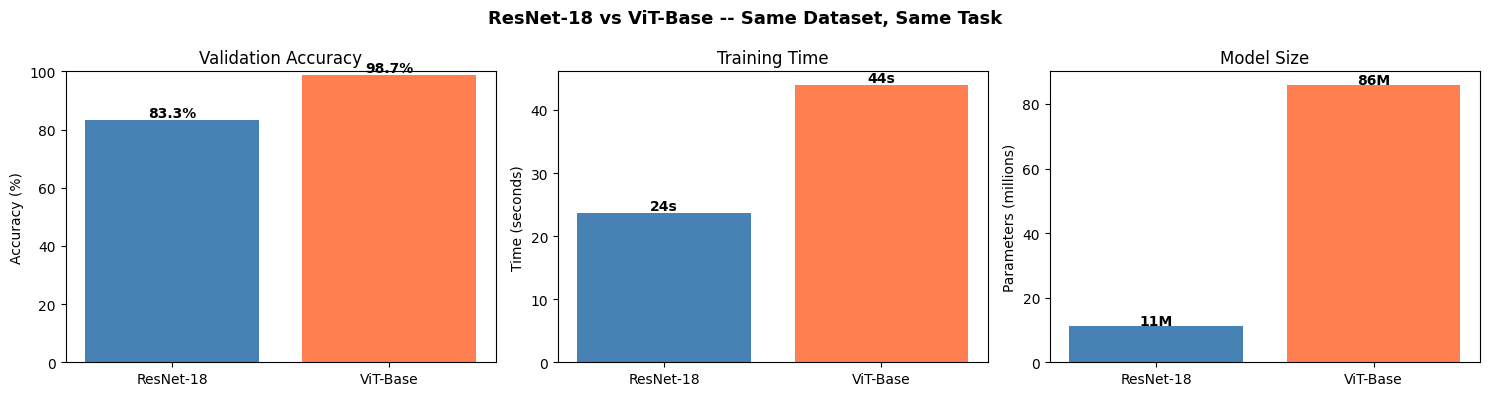

In [7]:
# STEP 4: Head-to-head comparison table
print("=" * 70)
print("HEAD-TO-HEAD COMPARISON: ResNet-18 vs ViT-Base")
print("=" * 70)

comparison = pd.DataFrame({
    'Metric': [
        'Val Accuracy (%)',
        'Training Time (s)',
        'Total Parameters',
        'Trainable Parameters',
        'Peak GPU Memory (MB)',
        'Model File Size (approx)',
        'Framework',
        'Training Pattern',
    ],
    'ResNet-18': [
        f"{resnet_val_acc:.1f}%",
        f"{resnet_time:.1f}s",
        f"{resnet_total_params:,}",
        f"{resnet_trainable:,}",
        f"{resnet_gpu_mem:.0f} MB",
        "~45 MB",
        "PyTorch (native)",
        "Manual training loop",
    ],
    'ViT-Base': [
        f"{vit_val_acc:.1f}%",
        f"{vit_time:.1f}s",
        f"{vit_total_params:,}",
        f"{vit_trainable:,}",
        f"{vit_gpu_mem:.0f} MB",
        "~330 MB",
        "HuggingFace Trainer",
        "Trainer API (automated)",
    ],
})
print(comparison.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy
axes[0].bar(['ResNet-18', 'ViT-Base'], [resnet_val_acc, vit_val_acc],
            color=['steelblue', 'coral'])
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Validation Accuracy')
axes[0].set_ylim(0, 100)
for i, v in enumerate([resnet_val_acc, vit_val_acc]):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Training time
axes[1].bar(['ResNet-18', 'ViT-Base'], [resnet_time, vit_time],
            color=['steelblue', 'coral'])
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Training Time')
for i, v in enumerate([resnet_time, vit_time]):
    axes[1].text(i, v + 0.5, f'{v:.0f}s', ha='center', fontweight='bold')

# Parameters
axes[2].bar(['ResNet-18', 'ViT-Base'], [resnet_total_params/1e6, vit_total_params/1e6],
            color=['steelblue', 'coral'])
axes[2].set_ylabel('Parameters (millions)')
axes[2].set_title('Model Size')
for i, v in enumerate([resnet_total_params/1e6, vit_total_params/1e6]):
    axes[2].text(i, v + 0.5, f'{v:.0f}M', ha='center', fontweight='bold')

plt.suptitle("ResNet-18 vs ViT-Base -- Same Dataset, Same Task", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 5: Ensemble -- Average Predictions from Both Models
> "Pro tip: Train 2-3 different models and average their predictions. This is how top Kaggle competitors win. Free accuracy boost."

ENSEMBLE: ResNet-18 + ViT-Base (averaged predictions)

Results on validation set:
  ResNet-18 alone:         83.3%
  ViT-Base alone:          97.4%
  ENSEMBLE (average):      91.0%
  Improvement over best:   -6.4%


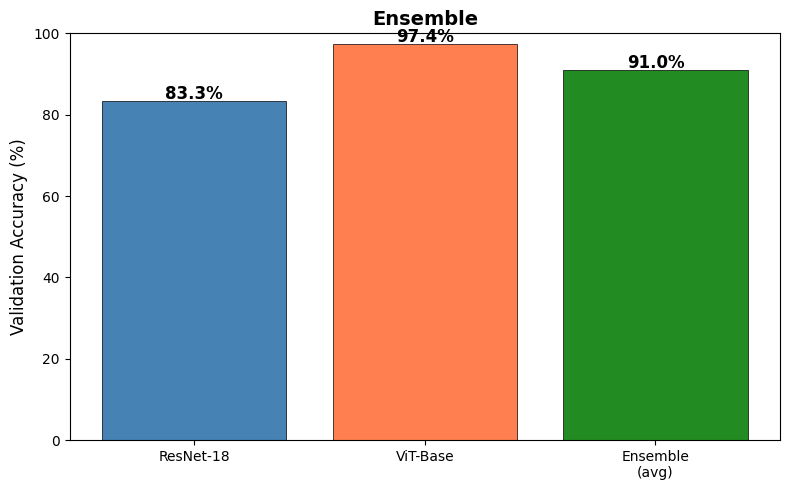

In [9]:
# STEP 5: Simple ensemble -- average predictions from both models
print("=" * 60)
print("ENSEMBLE: ResNet-18 + ViT-Base (averaged predictions)")
print("=" * 60)

# Get ResNet predictions (probabilities)
resnet_model.eval()
resnet_all_probs = []
all_true_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = resnet_model(images)
        probs = torch.softmax(outputs, dim=1)
        resnet_all_probs.append(probs.cpu().numpy())
        all_true_labels.extend(labels.numpy())

resnet_all_probs = np.concatenate(resnet_all_probs, axis=0)
all_true_labels = np.array(all_true_labels)

# Get ViT predictions (probabilities)
# We need to run ViT on the same validation images
vit_model.eval()
vit_all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        # ViT expects pixel_values, but we can pass our normalized tensors
        # through the processor's normalization. Since our transforms already
        # match ImageNet stats, we can use the model directly.
        outputs = vit_model(pixel_values=images)
        probs = torch.softmax(outputs.logits, dim=1)
        vit_all_probs.append(probs.cpu().numpy())

vit_all_probs = np.concatenate(vit_all_probs, axis=0)

# Ensemble: simple average of probabilities
ensemble_probs = (resnet_all_probs + vit_all_probs) / 2
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# Individual predictions
resnet_preds = np.argmax(resnet_all_probs, axis=1)
vit_preds = np.argmax(vit_all_probs, axis=1)

# Calculate accuracies
resnet_acc = accuracy_score(all_true_labels, resnet_preds) * 100
vit_acc = accuracy_score(all_true_labels, vit_preds) * 100
ensemble_acc = accuracy_score(all_true_labels, ensemble_preds) * 100

print(f"\nResults on validation set:")
print(f"  ResNet-18 alone:         {resnet_acc:.1f}%")
print(f"  ViT-Base alone:          {vit_acc:.1f}%")
print(f"  ENSEMBLE (average):      {ensemble_acc:.1f}%")
print(f"  Improvement over best:   {ensemble_acc - max(resnet_acc, vit_acc):.1f}%")

# Visualize
models_names = ['ResNet-18', 'ViT-Base', 'Ensemble\n(avg)']
accs = [resnet_acc, vit_acc, ensemble_acc]
colors = ['steelblue', 'coral', 'forestgreen']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models_names, accs, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Ensemble', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

---
## Cell 6: When to Use What -- Decision Guide

| Scenario | Use ResNet (PyTorch) | Use ViT (HuggingFace) |
|----------|---------------------|----------------------|
| Small dataset (<1000 images) | Preferred -- less data-hungry | May overfit |
| Large dataset (>10,000 images) | Good | Preferred -- scales better |
| Limited GPU / Colab free tier | Preferred -- much less memory | May run out of memory |
| Hackathon with tight deadline | Preferred -- faster training | Slower but possibly more accurate |
| Need highest accuracy | Good baseline | Usually wins with enough data |
| First attempt at a new task | Start here | Try second if ResNet is not enough |

### The Practical Decision:
1. **Always start with ResNet** (fast, low memory, works great on small data)
2. **If accuracy is not enough**, try ViT (bigger model, needs more data/compute)
3. **If you have time**, train BOTH and ensemble them (usually best of all)

### Key Takeaway:
The technique (transfer learning) matters more than the specific architecture. Both ResNet and ViT use the same principle: reuse pretrained features, replace the head, fine-tune. Pick whichever fits your constraints.